# First checks if all SNIa Have Associated HostGalaxy Coordiantes #

In [2]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("Pantheon_plus_DESI_match_data/all_redshifts_PVs.csv")

# Check for missing values in RA_host and Dec_host
missing_ra_host = df['RA_host'].isnull().sum()
missing_dec_host = df['Dec_host'].isnull().sum()

print(f"Missing RA_host: {missing_ra_host}")
print(f"Missing Dec_host: {missing_dec_host}")

# Create a mask for rows with valid RA_host and Dec_host
has_host_coords = df['RA_host'].notnull() & df['Dec_host'].notnull()

# Print how many entries have host coordinates
print(f"Entries with host coordinates: {has_host_coords.sum()}")

# Optionally, filter to just those rows
df_with_hosts = df[has_host_coords]

# Preview a few entries
print(df_with_hosts[['SNID', 'RA_host', 'Dec_host']].head())

Missing RA_host: 926
Missing Dec_host: 926
Entries with host coordinates: 1361
     SNID    RA_host  Dec_host
0  2001ah  167.62646  55.16983
1  2001az  248.62017  76.02972
2  2001da  358.38404   8.11814
3  2001en   21.33637  34.02494
4  2001fe  144.49167  25.49478


# Make a separate .csv file where all informaiton on SNIa with Missing Host Galaxy Coordiantes is Retained #

In [3]:

# Load  input CSV
df = pd.read_csv("Pantheon_plus_DESI_match_data/all_redshifts_PVs.csv")


# Filter rows where either RA_host or Dec_host is missing
missing_hosts_df = df[df['RA_host'].isnull() | df['Dec_host'].isnull()]

# Save to a new CSV file
output_path = "Pantheon_plus_DESI_match_data/all_redshifts_PVs_missing_host_coords.csv"
missing_hosts_df.to_csv(output_path, index=False)

print(f"Saved {len(missing_hosts_df)} entries with missing host coordinates to '{output_path}'")

Saved 926 entries with missing host coordinates to 'Pantheon_plus_DESI_match_data/all_redshifts_PVs_missing_host_coords.csv'


# Make a Molleweide Projection of the SNIa that do have Host Galaxy Properties Superimposed on DESI #

Has host galaxy info 2287
Does not have host galaxy info 926


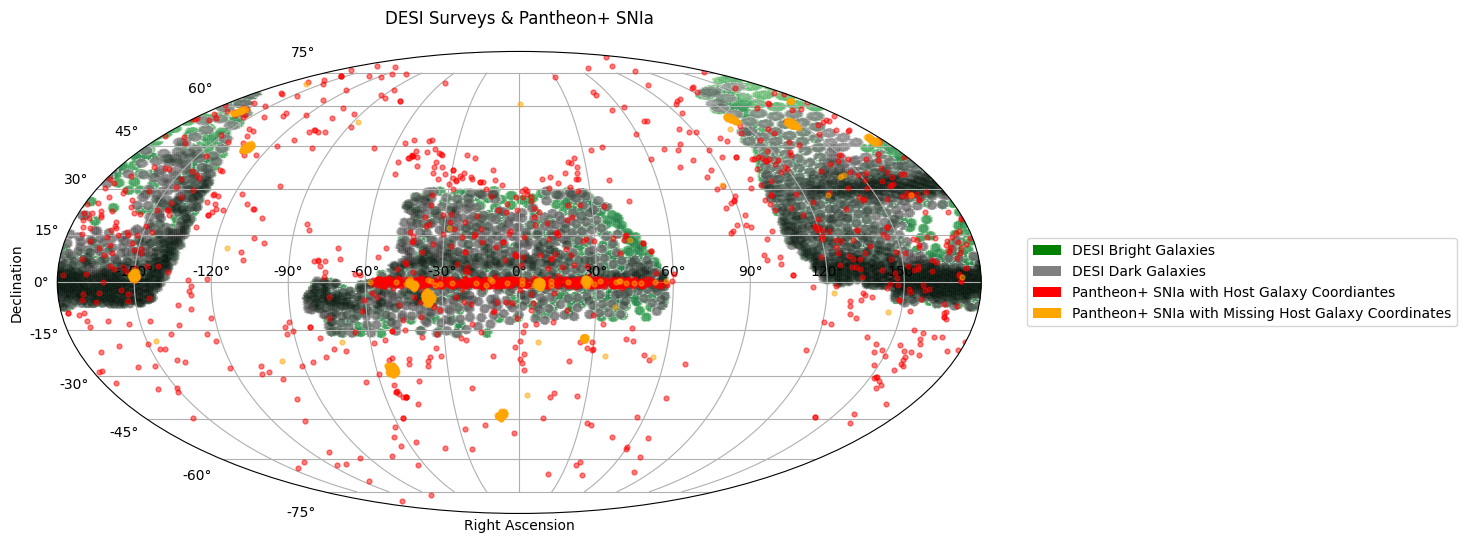

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch

def prepare_coords(ra_deg, dec_deg):
    """Convert RA/DEC from degrees to Mollweide-friendly radians."""
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra = np.remainder(ra + 2*np.pi, 2*np.pi)
    ra[ra > np.pi] -= 2*np.pi
    return -ra, dec

# === Load DESI Bright ===
bright = Table.read("DES5YR_DESI_match_data/desi_galaxy_metadata.fits")
ra_bright, dec_bright = prepare_coords(bright['RA'], bright['DEC'])

# === Load DESI Dark ===
dark = Table.read("DES5YR_DESI_match_data/desi_galaxy_metadata_dark.fits")
ra_dark, dec_dark = prepare_coords(dark['RA'], dark['DEC'])

# === Load Pantheon+ SNIa w/t Host Galaxy Information Inlcuded ===
# Note: we will be using Host Galaxy Coordiantes Here
snia_df = pd.read_csv("Pantheon_plus_DESI_match_data/all_redshifts_PVs.csv")
ra_hosts, dec_hosts = prepare_coords(snia_df['RA_host'], snia_df['Dec_host'])

# === Load Pantheon+ SNIa w/t Missing Host Galaxy Informaiton ===
# NOte: we will be using the Actual SNIa coordiantes here.
missing_df = pd.read_csv("Pantheon_plus_DESI_match_data/all_redshifts_PVs_missing_host_coords.csv")
ra_snia_missing, dec_snia_missing = prepare_coords(missing_df['RA'], missing_df['Dec'])


# === Plot ===
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

# Flatten arrays for hexbin
x_bright, y_bright = ra_bright.flatten(), dec_bright.flatten()
x_dark, y_dark = ra_dark.flatten(), dec_dark.flatten()

# Hexbin with LogNorm for density contrast

# DESI Bright (density)
hb1 = ax.hexbin(x_bright, y_bright, gridsize=500, cmap='Greens',
                mincnt=1, linewidths=0, norm=LogNorm())

# DESI Dark (density)
hb2 = ax.hexbin(x_dark, y_dark, gridsize=500, cmap='Greys',
                mincnt=1, linewidths=0, norm=LogNorm())


# SNIa with included Host Galaxy Information
# Note: Host Galaxy coordiantes
ax.plot(ra_hosts, dec_hosts, 'r.', markersize=7, alpha=0.5, label='Pantheon+ Host Galaxies')
print("Has host galaxy info " + str(len(ra_hosts)))

# SNIa with missing Host Galaxy Infroamtion
# Note: the SNIa coordaintes are included in there
ax.plot(ra_snia_missing, dec_snia_missing, '.', color = "orange", markersize=7, alpha=0.5, label='Pantheon+ SNIa (No Host Info)')
print("Does not have host galaxy info " + str(len(ra_snia_missing)))



# Legend using dummy patches
legend_elements = [
    Patch(facecolor='green', label='DESI Bright Galaxies', alpha=1),
    Patch(facecolor='gray', label='DESI Dark Galaxies', alpha=1),
    Patch(facecolor='red', label='Pantheon+ SNIa with Host Galaxy Coordiantes', alpha=1),
    Patch(facecolor='orange', label='Pantheon+ SNIa with Missing Host Galaxy Coordinates', alpha=1)
]
# External legend
ax.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    borderaxespad=0.,
    frameon=True
)
# Plot settings
ax.set_title('DESI Surveys & Pantheon+ SNIa', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
plt.show()

# See If Any of the SNIa Between DES5YR and Pantheon + are the same so as to avoid Double Counting #

In [27]:
# First Lets Look at the Content of the Pantheon+SH0ES .dat File #

# Adjust path to where the file is on your system
file_path = "Pantheon_plus_DESI_match_data/Pantheon+SH0ES.dat"

# Load the .dat file
df = pd.read_csv(file_path, delim_whitespace=True)

# Show first few rows and column names
print(len(df))

print(df[['HOST_RA', 'HOST_DEC']])

1701
      HOST_RA  HOST_DEC
0        -999      -999
1        -999      -999
2        -999      -999
3        -999      -999
4        -999      -999
...       ...       ...
1696     -999      -999
1697     -999      -999
1698     -999      -999
1699     -999      -999
1700     -999      -999

[1701 rows x 2 columns]


/tmp/ipykernel_2193589/1365409496.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)
